# ViT Position Encoding Analysis: SSDC, RPI, and Layer Windowed Ablation

This notebook reproduces the spatial structure analysis for two pretrained Vision Transformers, then runs a new mechanistic ablation experiment.

**Models**
- APE: `google/vit-base-patch16-224` (learned absolute position embeddings), via transformers.
- RoPE: `vit_base_patch16_rope_224.naver_in1k` (rotary position embeddings), via timm.

**Data**: ImageNet-1k validation, streamed from the Hugging Face Hub (gated, needs a token).

**What runs here**
1. SSDC across depth, clean and under Random Permutation at Inference (RPI), for both models.
2. Robustness (fragility) under ImageNet-C Gaussian blur.
3. The new experiment: zero ablating MLP or attention sublayers in early, middle, or late layer windows for the APE model. This asks whether the early SSDC peak is tied to the early MLPs specifically or just to the first MLPs the tokens meet, and whether removing attention only in later layers still flattens the later layer SSDC decay.
4. Extension: effective rank across depth and its collapse under MLP ablation (Dong et al., 2021).

Guidance paper: Mannes, *Positional Encodings Anchor Spatial Structure in Vision Transformers* (arXiv 2606.00124). The experiments here are our own and use pretrained ViT-Base models, not the from scratch ViT-S setup in that paper.

Use a GPU runtime (Runtime > Change runtime type > GPU).

## 0. Setup

In [3]:
# Colab already ships torch, numpy, scipy, matplotlib, Pillow.
!pip -q install timm transformers datasets scikit-image huggingface_hub

In [4]:
import os, sys

REPO = 'vit-sae-analysis'
if not os.path.exists(REPO):
    !git clone https://github.com/aravinds-kannappan/vit-sae-analysis.git

SRC = os.path.abspath(os.path.join(REPO, 'project_code', 'src'))
if SRC not in sys.path:
    sys.path.insert(0, SRC)
print('src on path:', SRC)

# Optional: mount Drive to persist figures and results.
# from google.colab import drive
# drive.mount('/content/drive')

Cloning into 'vit-sae-analysis'...
remote: Enumerating objects: 333, done.
remote: Counting objects: 100% (333/333), done.
remote: Compressing objects: 100% (223/223), done.
remote: Total 333 (delta 88), reused 310 (delta 65), pack-reused 0 (from 0)
Receiving objects: 100% (333/333), 87.01 KiB | 14.50 MiB/s, done.
Resolving deltas: 100% (88/88), done.
src on path: /content/vit-sae-analysis/project_code/src


In [5]:
# ImageNet-1k is gated. Your token must be able to READ gated repos:
#   1. Accept the terms once at https://huggingface.co/datasets/ILSVRC/imagenet-1k
#   2. Use EITHER a classic 'Read' token, OR a fine-grained token with
#      'Read access to contents of all public gated repos you can access'
#      enabled at https://huggingface.co/settings/tokens
# If the token still cannot read it, the dataset cell auto-falls back to an
# ungated mirror (benjamin-paine/imagenet-1k-256x256) so the notebook still runs.
import os, getpass
if not os.environ.get('HF_TOKEN'):
    os.environ['HF_TOKEN'] = getpass.getpass('Hugging Face token: ')
from huggingface_hub import login
login(os.environ['HF_TOKEN'], add_to_git_credential=False)

Hugging Face token: ··········


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [6]:
import torch
import matplotlib.pyplot as plt
from experiments import common, reproduce_ssdc, reproduce_robustness, ablation_layerwise, effective_rank_probe

print('device:', 'cuda' if torch.cuda.is_available() else 'cpu (slow, switch to a GPU runtime)')

# Sample sizes. Raise for smoother curves, lower for a quick pass.
NUM_IMAGES = 1000
BATCH_SIZE = 128
ABLATION_IMAGES = 512   # the ablation sweep runs many conditions, keep it modest

# Stream ImageNet-1k validation once and reuse it (re-iterating restarts the stream).
# ILSVRC/imagenet-1k is gated. If your account has not accepted its terms you get a
# 403, and this call auto-falls back to the ungated mirror
# benjamin-paine/imagenet-1k-256x256 (same schema and 0-999 labels). To use the
# official split, click 'Agree and access repository' at
# https://huggingface.co/datasets/ILSVRC/imagenet-1k then rerun this cell.
dataset = common.load_imagenet(split='validation', streaming=True)

device: cuda


README.md:   0%|          | 0.00/87.6k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

loaded ILSVRC/imagenet-1k [validation]


## 1. SSDC across depth, clean and under RPI

APE should show SSDC under RPI peaking early (blocks 2 to 3) then decaying with depth. RoPE should accumulate more gradually and peak later. Dashed lines are the reference curves stored in the repo.

=== APE ===


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

clean: [0.455, 0.59, 0.725, 0.724, 0.704, 0.67, 0.652, 0.632, 0.635, 0.637, 0.646, 0.693]
rpi:   [0.454, 0.519, 0.754, 0.817, 0.817, 0.746, 0.627, 0.512, 0.436, 0.394, 0.352, 0.198]
saved /content/vit-sae-analysis/results/figures/ssdc_ape.png
=== ROPE ===


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

clean: [0.666, 0.656, 0.711, 0.725, 0.757, 0.783, 0.777, 0.754, 0.736, 0.716, 0.668, 0.538]
rpi:   [0.001, 0.045, 0.132, 0.332, 0.556, 0.643, 0.598, 0.583, 0.617, 0.589, 0.51, 0.473]
saved /content/vit-sae-analysis/results/figures/ssdc_rope.png


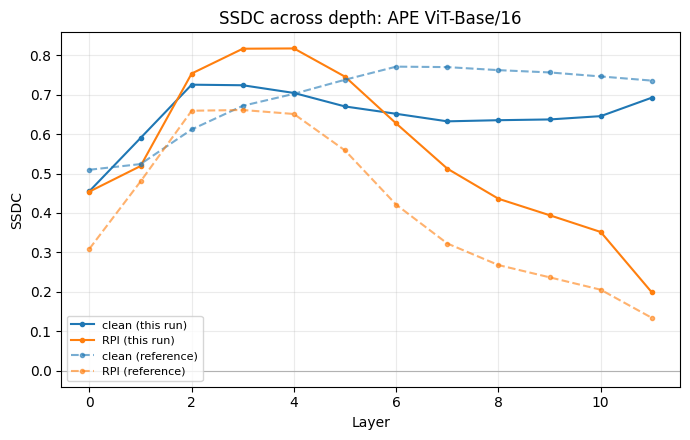

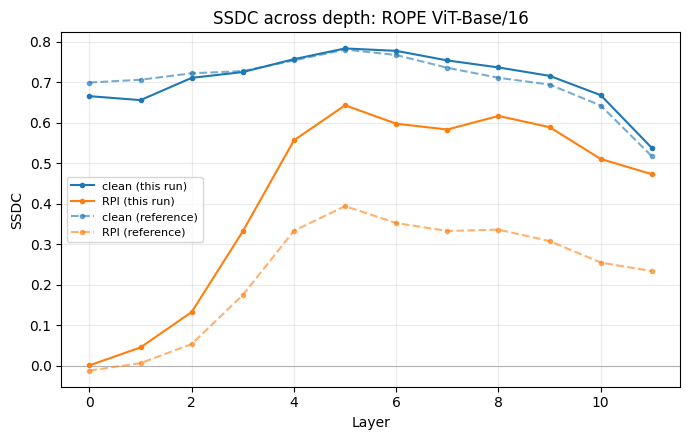

In [7]:
ssdc_results = {}
for kind in ['ape', 'rope']:
    print(f'=== {kind.upper()} ===')
    ssdc_results[kind] = reproduce_ssdc.run_model(kind, dataset, number_images=NUM_IMAGES, batch_size=BATCH_SIZE)
    print('clean:', [round(x, 3) for x in ssdc_results[kind]['clean']])
    print('rpi:  ', [round(x, 3) for x in ssdc_results[kind]['rpi']])
    reproduce_ssdc.plot_model(kind, ssdc_results[kind])
plt.show()

## 2. Robustness under Gaussian blur

Fragility = 1 - shifted / baseline accuracy under ImageNet-C Gaussian blur (severity 5). Reference: APE 0.326, RoPE 0.299 (RoPE is the more robust).

In [8]:
rob = {}
for kind in ['ape', 'rope']:
    rob[kind] = reproduce_robustness.run_model(kind, dataset, corruption='Gaussian Blur', severity=5,
                                               number_images=NUM_IMAGES, batch_size=BATCH_SIZE)

print('\nmodel   baseline  shifted  fragility')
for kind in ['ape', 'rope']:
    r = rob[kind]
    print(f"{kind:5s}   {r['baseline_accuracy']:.3f}    {r['shifted_accuracy']:.3f}    {r['fragility']:.3f}")

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]


model   baseline  shifted  fragility
ape     0.805    0.495    0.385
rope    0.844    0.607    0.281


## 3. New experiment: layer windowed MLP and attention ablation (APE)

Windows: early = [0,1,2,3], mid = [4,5,6,7], late = [8,9,10,11]. Primary metric is SSDC under RPI, since both the early peak and the later decay live in that curve for APE. This runs about twelve conditions, so give it a few minutes on a GPU. Three figures are produced: MLP ablation by window, keep MLPs in one window only, and attention ablation by window.

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

-- condition: baseline (RPI) --
    [0.409, 0.515, 0.736, 0.786, 0.785, 0.71, 0.583, 0.471, 0.4, 0.361, 0.321, 0.204]
-- condition: mlp_zero_early (RPI) --
    [0.398, 0.454, 0.691, 0.771, 0.782, 0.729, 0.484, 0.389, 0.369, 0.356, 0.315, 0.266]
-- condition: mlp_zero_mid (RPI) --
    [0.398, 0.511, 0.732, 0.777, 0.774, 0.734, 0.69, 0.657, 0.583, 0.525, 0.494, 0.476]
-- condition: mlp_zero_late (RPI) --
    [0.414, 0.514, 0.737, 0.78, 0.776, 0.695, 0.562, 0.447, 0.375, 0.352, 0.323, 0.188]
-- condition: mlp_zero_all (RPI) --
    [0.417, 0.46, 0.698, 0.78, 0.788, 0.771, 0.735, 0.723, 0.704, 0.692, 0.683, 0.677]
-- condition: mlp_keep_early (RPI) --
    [0.399, 0.508, 0.732, 0.776, 0.776, 0.736, 0.694, 0.661, 0.587, 0.547, 0.505, 0.486]
-- condition: mlp_keep_mid (RPI) --
    [0.416, 0.461, 0.699, 0.781, 0.794, 0.742, 0.495, 0.397, 0.375, 0.373, 0.348, 0.315]
-- condition: mlp_keep_late (RPI) --
    [0.391, 0.453, 0.685, 0.762, 0.777, 0.757, 0.719, 0.704, 0.689, 0.664, 0.655, 0.647]
-- co

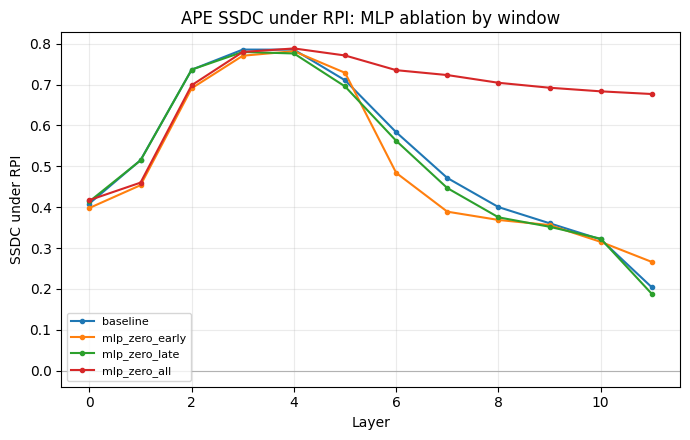

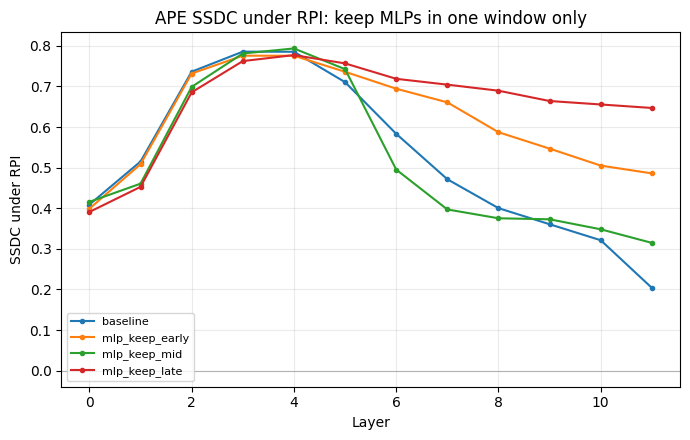

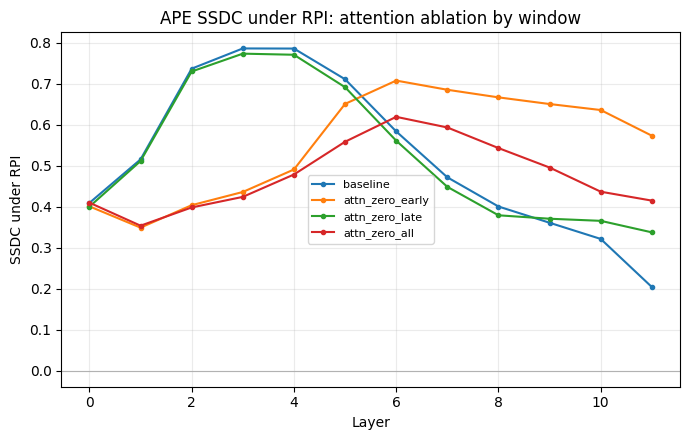

In [9]:
abl = ablation_layerwise.run_all(dataset, model_kind='ape',
                                 number_images=ABLATION_IMAGES, batch_size=BATCH_SIZE,
                                 do_rank=False, do_plot=True)
plt.show()

### Reading the ablation result

- **MLP claim**: `mlp_zero_all` should crush SSDC under RPI toward zero at all depths. That is the *MLPs carry the index anchored recovery* signal.
- **Early MLP specificity**: compare `mlp_zero_early` with `mlp_zero_late`. If early ablation removes the early peak but late ablation leaves it, the peak is tied to the early MLP blocks.
- **First blocks encountered**: look at `mlp_keep_early`, `mlp_keep_mid`, `mlp_keep_late`. If the peak layer follows the surviving window (a later kept window gives a later peak), the peak tracks the first surviving MLPs rather than depth itself.
- **Attention and the later decay**: `attn_zero_all` should shrink the decay (SSDC stays elevated late). If `attn_zero_late` alone also shrinks it, the later layer decay is driven by attention in the late blocks specifically.

The printed summary table gives peak, peak_layer, delta, decay, final, and auc per condition to back these reads with numbers.

## 4. Extension: effective rank and rank collapse (Dong et al., 2021)

Attention without MLPs drives token representations toward rank one with depth. If MLP ablation collapses effective rank where it also collapses SSDC recovery, that links a representational capacity failure to the spatial structure failure, which is a mechanistic account rather than a correlation.

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

-- effective rank: baseline --
    [99.02, 129.36, 151.06, 154.42, 154.01, 150.67, 145.21, 141.51, 139.28, 139.68, 140.71, 137.26]
-- effective rank: mlp_zero_all --
    [99.0, 107.83, 123.91, 126.38, 121.16, 113.65, 103.27, 94.21, 80.99, 70.69, 58.55, 43.03]
-- effective rank: attn_zero_all --
    [98.7, 122.83, 125.89, 122.3, 119.79, 115.88, 112.99, 111.42, 111.71, 114.66, 123.51, 136.1]


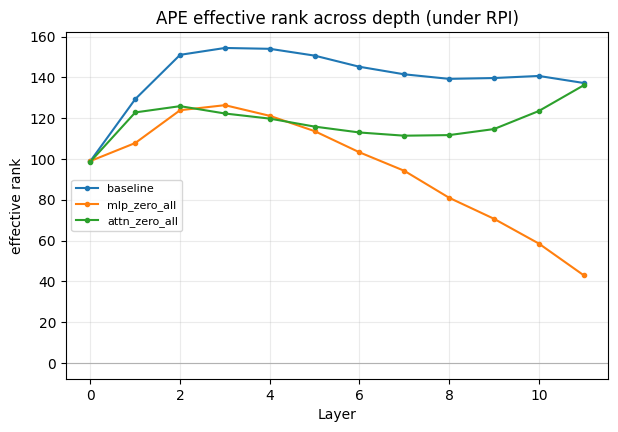

In [10]:
rank_curves = effective_rank_probe.run('ape', dataset, number_images=ABLATION_IMAGES,
                                       batch_size=BATCH_SIZE, rpi=True)
common.plot_curves(rank_curves, title='APE effective rank across depth (under RPI)', ylabel='effective rank')
plt.show()

## Notes and next steps

- Every curve depends on the sampled images, so numbers vary slightly run to run. Raise `NUM_IMAGES` for tighter estimates.
- The ablated (trained without PE) and RPT conditions from the guidance paper need training from scratch and are out of scope for this pretrained study.
- Natural extensions: sweep the ablation window boundary layer by layer to find where the decay switches on, repeat the ablation study on RoPE to see whether its gradual accumulation responds differently, and connect ablation to the SAE features in `project_code/src/SAE`.